# BehaviorGuard — Final Credit Card Fraud Detection Analysis

This is the consolidated final analysis file for the project.

## 01. Imports and Configuration

In [2]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, chi2_contingency, rankdata
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    balanced_accuracy_score
)

import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

DATA_PATH = Path("../data/processed/transactions_behavioral.csv")
RESULT_DIR = Path("../results/final_analysis")
FIGURE_DIR = RESULT_DIR / "figures"
MODEL_DIR = RESULT_DIR / "models"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print("Environment setup complete. All necessary libraries imported and directories created.")


Environment setup complete. All necessary libraries imported and directories created.


## 02. Load Data and Analysis Dataset

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Processed dataset not found:\n{DATA_PATH.resolve()}\n\n"
        "Make sure the processed dataset is located at "
        "../data/processed/transactions_behavioral.csv"
    )

df = pd.read_csv(DATA_PATH)

print("\n[1] DATASET")
print("-" * 80)
print("Shape:", df.shape)
print("Columns:", len(df.columns))

if "Class" not in df.columns:
    raise ValueError("Target column 'Class' was not found.")

print("\nTarget distribution:")
print(df["Class"].value_counts())

print("\nTarget percentage:")
print((df["Class"].value_counts(normalize=True) * 100).round(4))



[1] DATASET
--------------------------------------------------------------------------------
Shape: (283726, 39)
Columns: 39

Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Target percentage:
Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64


In [4]:
print("\n[2] DATA QUALITY")
print("-" * 80)

missing = df.isna().sum()
missing = missing[missing > 0]

print("Missing values:")
print(missing if not missing.empty else "None")

print("\nDuplicate rows:", int(df.duplicated().sum()))

print("\nTarget values:", sorted(df["Class"].dropna().unique().tolist()))

if df["Class"].isna().any():
    raise ValueError("Target contains missing values.")

# Remove exact duplicate rows only if any are found.
# The project dataset previously contained zero duplicates, so this should
# normally leave the dataset unchanged.
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New shape:", df.shape)



[2] DATA QUALITY
--------------------------------------------------------------------------------
Missing values:
None

Duplicate rows: 0

Target values: [0, 1]


## Feature Engineering for Final Analysis

In [9]:


# Temporal analysis feature.
# This is derived from Time and is used for analysis, not as raw Time input.
if "Time" in df.columns:
    df["Transaction_Hour"] = (df["Time"] / 3600.0) % 24
    df["Transaction_Hour_Int"] = df["Transaction_Hour"].astype(int)

# Identifiers / technical columns that should not be learned as predictors.
EXCLUDE_COLUMNS = {
    "Class",
    "level_0",
    "index",
    "Transaction_Time",
    "Transaction_Hour",
    "Transaction_Hour_Int",
}

feature_columns = [
    c for c in df.columns
    if c not in EXCLUDE_COLUMNS
]

In [10]:
# Behavioral features already engineered earlier in the project.
BEHAVIORAL_FEATURES = [
    "Amount_Log",
    "Amount_Category",
    "Transactions_Last_1H",
    "Transactions_Last_24H",
    "Amount_ZScore",
]

BEHAVIORAL_FEATURES = [
    c for c in BEHAVIORAL_FEATURES if c in df.columns
]

In [11]:
# Numeric/categorical split.
numeric_features = [
    c for c in feature_columns
    if pd.api.types.is_numeric_dtype(df[c])
]

categorical_features = [
    c for c in feature_columns
    if not pd.api.types.is_numeric_dtype(df[c])
]

In [12]:
print("Total model features:", len(feature_columns))
print("Numerical features:", len(numeric_features))
print("Categorical features:", categorical_features)
print("Behavioral features:", BEHAVIORAL_FEATURES)


Total model features: 37
Numerical features: 35
Categorical features: ['Time_Period', 'Amount_Category']
Behavioral features: ['Amount_Log', 'Amount_Category', 'Transactions_Last_1H', 'Transactions_Last_24H', 'Amount_ZScore']


## 04. Class Counts

In [16]:

normal_count = int((df["Class"] == 0).sum())
fraud_count = int((df["Class"] == 1).sum())
fraud_rate = fraud_count / len(df)

print("\n[4] CLASS BALANCE : \n")

print(f"Normal transactions : {normal_count:,}")
print(f"Fraud transactions  : {fraud_count:,}")
print(f"Fraud rate          : {fraud_rate:.4%}")




[4] CLASS BALANCE : 

Normal transactions : 283,253
Fraud transactions  : 473
Fraud rate          : 0.1667%


## 05. Leakage-Safe Train / Validation / Test Split

First, split off 20% as the test set. From the remaining 80%, create a 20% validation split. This produces approximately 64% training, 16% validation, and 20% test data.

In [18]:


X = df[feature_columns].copy()
y = df["Class"].astype(int).copy()

# First split off 20% test data.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)


In [20]:
# From the remaining 80%, create a 20% validation split.
# This produces approximately:
#   64% train, 16% validation, 20% test.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)


In [21]:
print("Train:", X_train.shape, "Fraud:", int(y_train.sum()))
print("Valid:", X_valid.shape, "Fraud:", int(y_valid.sum()))
print("Test :", X_test.shape, "Fraud:", int(y_test.sum()))


Train: (181584, 37) Fraud: 302
Valid: (45396, 37) Fraud: 76
Test : (56746, 37) Fraud: 95


## 06. Preprocessing Pipeline

- Numeric features: median imputation and standardization
- Categorical features: most-frequent imputation and one-hot encoding

The preprocessing is fit only on the training data through the Pipeline and ColumnTransformer, preventing leakage.

In [22]:

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

In [23]:

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)


## 07. Model Definitions

Class imbalance is severe, so class_weight="balanced" is used for the scikit-learn models. For XGBoost, scale_pos_weight is calculated from the training data only.

In [27]:
scale_pos_weight = (
    (len(y_train) - int(y_train.sum()))
    / max(int(y_train.sum()), 1)
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=2
    ),
}

# XGBoost is optional only in the sense that the script gives a clear error
# if the package is not installed. The project already used XGBoost.
try:
    from xgboost import XGBClassifier

    models["XGBoost"] = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

except ImportError as exc:
    raise ImportError(
        "XGBoost is required for the final project analysis. "
        "Install it with: pip install xgboost"
    ) from exc



## 08. Train Models and Collect Validation / Test Scores

In [29]:
fitted_models = {}
model_results = []
validation_probabilities = {}
test_probabilities = {}

for model_name, estimator in models.items():

    print(f"\nTraining {model_name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    pipeline.fit(X_train, y_train)

    fitted_models[model_name] = pipeline

    # Validation probabilities are used only for threshold selection.
    valid_prob = pipeline.predict_proba(X_valid)[:, 1]

    # Test probabilities are reserved for final evaluation.
    test_prob = pipeline.predict_proba(X_test)[:, 1]

    validation_probabilities[model_name] = valid_prob
    test_probabilities[model_name] = test_prob

    # Default 0.50 threshold metrics.
    test_pred = (test_prob >= 0.50).astype(int)

    precision = precision_score(
        y_test, test_pred, zero_division=0
    )
    recall = recall_score(
        y_test, test_pred, zero_division=0
    )
    f1 = f1_score(
        y_test, test_pred, zero_division=0
    )
    pr_auc = average_precision_score(
        y_test, test_prob
    )
    roc_auc = roc_auc_score(
        y_test, test_prob
    )
    balanced_acc = balanced_accuracy_score(
        y_test, test_pred
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test, test_pred
    ).ravel()

    model_results.append({
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc,
        "Balanced_Accuracy": balanced_acc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })



Training Logistic Regression...

Training Random Forest...

Training XGBoost...


In [33]:
# Save fitted model for each trained estimator.
safe_name = (
    model_name.lower()
    .replace(" ", "_")
)

joblib.dump(
    pipeline,
    MODEL_DIR / f"{safe_name}.joblib"
)

model_results_df = pd.DataFrame(model_results)

print("\nModel benchmark:")
print(
    model_results_df[
        [
            "Model",
            "Precision",
            "Recall",
            "F1",
            "PR_AUC",
            "ROC_AUC",
            "Balanced_Accuracy",
        ]
    ].round(4).to_string(index=False)
)



Model benchmark:
              Model  Precision  Recall     F1  PR_AUC  ROC_AUC  Balanced_Accuracy
Logistic Regression     0.0507  0.8737 0.0958  0.6896   0.9694             0.9231
      Random Forest     0.9459  0.7368 0.8284  0.8118   0.9489             0.8684
            XGBoost     0.9259  0.7895 0.8523  0.8105   0.9662             0.8947


## 09. Confusion Matrices

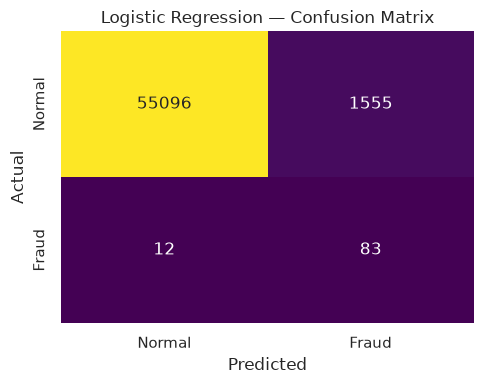

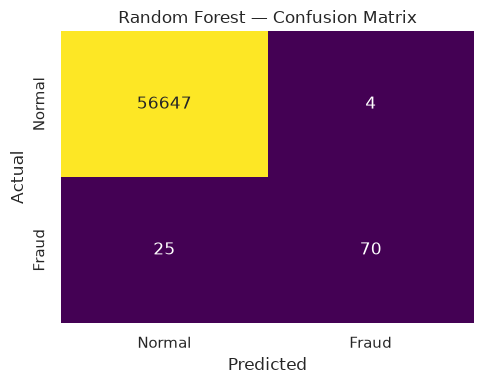

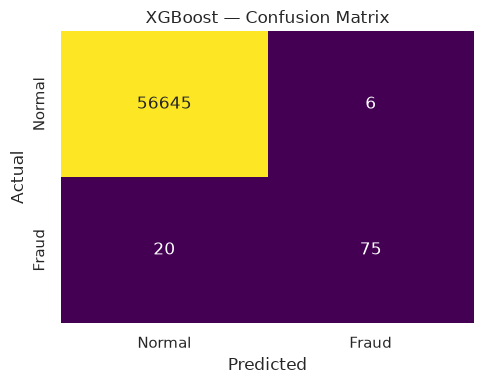

In [40]:
for model_name, test_prob in test_probabilities.items():

    test_pred = (test_prob >= 0.50).astype(int)
    cm = confusion_matrix(y_test, test_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False,
        xticklabels=["Normal", "Fraud"],
        yticklabels=["Normal", "Fraud"],
        cmap="viridis"
    )

    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    filename = (
        model_name.lower()
        .replace(" ", "_")
        + "_confusion_matrix.png"
    )

    plt.show()

    plt.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()



## 10. Precision-Recall and ROC Curves

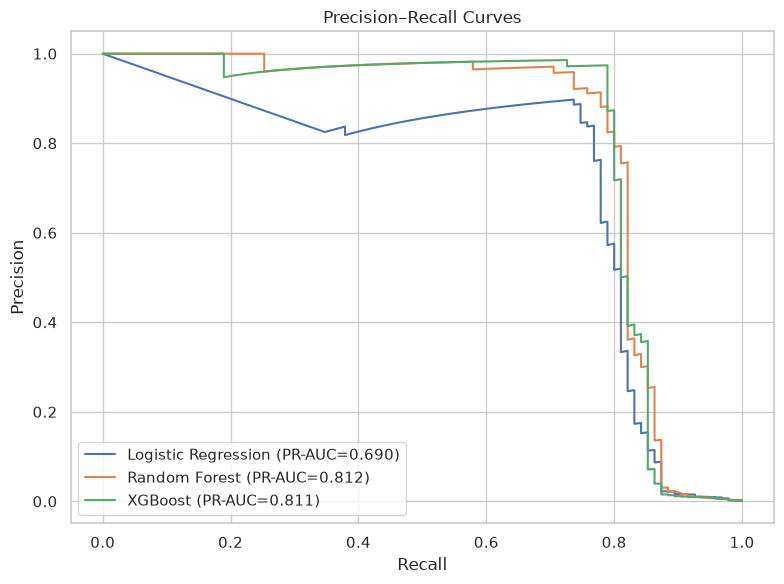

In [41]:
plt.figure(figsize=(8, 6))

for model_name, test_prob in test_probabilities.items():

    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test,
        test_prob
    )

    pr_auc = average_precision_score(
        y_test,
        test_prob
    )

    plt.plot(
        recall_curve,
        precision_curve,
        label=f"{model_name} (PR-AUC={pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.tight_layout()

plt.show()

plt.savefig(
    FIGURE_DIR / "precision_recall_curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

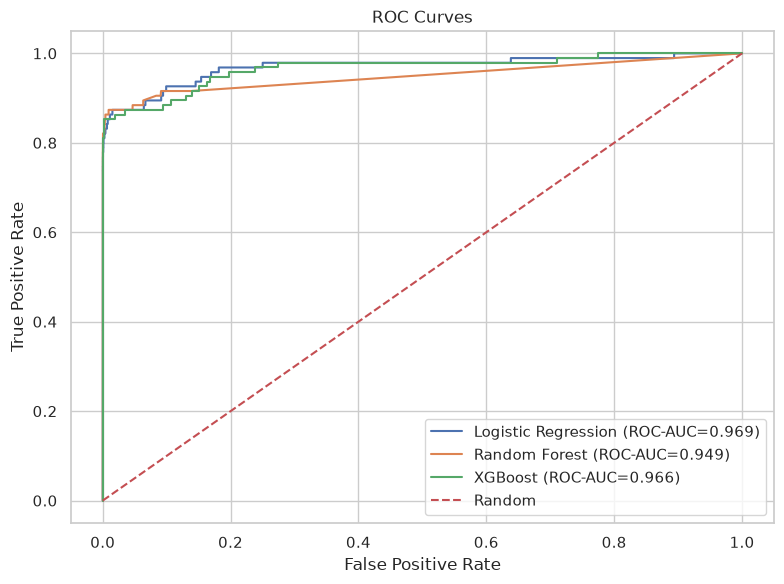

In [42]:
plt.figure(figsize=(8, 6))

for model_name, test_prob in test_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        test_prob
    )

    roc_auc = roc_auc_score(
        y_test,
        test_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (ROC-AUC={roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()

plt.show()

plt.savefig(
    FIGURE_DIR / "roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

## 11. Validation-Based Threshold Analysis for XGBoost

In [43]:
xgb_valid_prob = validation_probabilities["XGBoost"]

threshold_grid = np.arange(
    0.05,
    0.951,
    0.01
)

threshold_rows = []

for threshold in threshold_grid:

    pred = (
        xgb_valid_prob >= threshold
    ).astype(int)

    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_valid, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_valid, pred, zero_division=0
        ),
        "F1": f1_score(
            y_valid, pred, zero_division=0
        ),
    })

threshold_df = pd.DataFrame(threshold_rows)


In [44]:
# Select threshold by validation F1.
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = float(
    best_row["Threshold"]
)

print(
    "Best validation threshold by F1:",
    round(best_threshold, 2)
)

print(
    best_row.to_string()
)

threshold_df.to_csv(
    RESULT_DIR / "xgboost_threshold_analysis.csv",
    index=False
)


Best validation threshold by F1: 0.54
Threshold    0.540000
Precision    0.970149
Recall       0.855263
F1           0.909091


In [45]:
# Apply the selected threshold once to the untouched test set.
xgb_test_prob = test_probabilities["XGBoost"]

xgb_default_pred = (
    xgb_test_prob >= 0.50
).astype(int)

xgb_tuned_pred = (
    xgb_test_prob >= best_threshold
).astype(int)

threshold_comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1"
    ],

    "Default_0.50": [
        precision_score(
            y_test,
            xgb_default_pred,
            zero_division=0
        ),
        recall_score(
            y_test,
            xgb_default_pred,
            zero_division=0
        ),
        f1_score(
            y_test,
            xgb_default_pred,
            zero_division=0
        )
    ],

    "Validation_Selected_Threshold": [
        precision_score(
            y_test,
            xgb_tuned_pred,
            zero_division=0
        ),
        recall_score(
            y_test,
            xgb_tuned_pred,
            zero_division=0
        ),
        f1_score(
            y_test,
            xgb_tuned_pred,
            zero_division=0
        )
    ]
})

In [46]:
threshold_comparison.to_csv(
    RESULT_DIR / "xgboost_threshold_comparison.csv",
    index=False
)

print("\nXGBoost threshold comparison:")
print(
    threshold_comparison.round(4).to_string(index=False)
)



XGBoost threshold comparison:
   Metric  Default_0.50  Validation_Selected_Threshold
Precision        0.9259                         0.9259
   Recall        0.7895                         0.7895
       F1        0.8523                         0.8523


## 12. Statistical Analysis - Numerical Features

In [47]:
normal_df = df[df["Class"] == 0]
fraud_df = df[df["Class"] == 1]

statistical_numeric_features = [
    c for c in df.columns
    if c not in {
        "Class",
        "level_0",
        "index",
        "Transaction_Time",
        "Transaction_Hour_Int",
    }
    and pd.api.types.is_numeric_dtype(df[c])
]


def cliffs_delta(x, y):
    """
    Cliff's Delta for two independent samples.

    x = fraud group
    y = normal group

    Positive:
        fraud values tend to be larger.

    Negative:
        fraud values tend to be smaller.

    Magnitude:
        < 0.147   negligible
        < 0.33    small
        < 0.474   medium
        >= 0.474  large
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]

    nx = len(x)
    ny = len(y)

    if nx == 0 or ny == 0:
        return np.nan

    combined = np.concatenate([x, y])
    ranks = rankdata(combined)

    rank_x = ranks[:nx]

    U = (
        rank_x.sum()
        - nx * (nx + 1) / 2
    )

    return (
        (2 * U) / (nx * ny)
    ) - 1


In [48]:
def effect_label(delta):
    magnitude = abs(delta)

    if magnitude < 0.147:
        return "Negligible"
    elif magnitude < 0.33:
        return "Small"
    elif magnitude < 0.474:
        return "Medium"
    return "Large"


stat_rows = []

for feature in statistical_numeric_features:

    normal_values = normal_df[feature].dropna().values
    fraud_values = fraud_df[feature].dropna().values

    if len(normal_values) == 0 or len(fraud_values) == 0:
        continue

    u_stat, p_value = mannwhitneyu(
        normal_values,
        fraud_values,
        alternative="two-sided"
    )

    delta = cliffs_delta(
        fraud_values,
        normal_values
    )

    stat_rows.append({
        "Feature": feature,
        "Normal_Median": np.median(normal_values),
        "Fraud_Median": np.median(fraud_values),
        "U_Statistic": u_stat,
        "P_Value": p_value,
        "Cliffs_Delta": delta,
        "Absolute_Cliffs_Delta": abs(delta),
        "Effect_Size": effect_label(delta),
    })


In [49]:
stat_df = pd.DataFrame(stat_rows)

reject, adjusted_p, _, _ = multipletests(
    stat_df["P_Value"],
    alpha=0.05,
    method="fdr_bh"
)

stat_df["Adjusted_P_Value"] = adjusted_p
stat_df["Significant"] = reject

stat_df = stat_df.sort_values(
    "Absolute_Cliffs_Delta",
    ascending=False
)

stat_df.to_csv(
    RESULT_DIR / "statistical_numerical_features.csv",
    index=False
)

print("\nTop statistical features:")
print(
    stat_df[
        [
            "Feature",
            "Normal_Median",
            "Fraud_Median",
            "Adjusted_P_Value",
            "Cliffs_Delta",
            "Effect_Size",
        ]
    ].head(20).round(6).to_string(index=False)
)




Top statistical features:
Feature  Normal_Median  Fraud_Median  Adjusted_P_Value  Cliffs_Delta Effect_Size
    V14       0.051486     -6.590550               0.0     -0.894278       Large
     V4      -0.024500      4.100098               0.0      0.872511       Large
    V12       0.140573     -5.437354               0.0     -0.868913       Large
    V11      -0.034446      3.525726               0.0      0.829646       Large
    V10      -0.092120     -4.466284               0.0     -0.821164       Large
     V3       0.182247     -4.875397               0.0     -0.817280       Large
     V2       0.062561      2.617105               0.0      0.699607       Large
    V16       0.068100     -3.302899               0.0     -0.682871       Large
     V9      -0.051368     -2.099049               0.0     -0.682572       Large
     V7       0.041664     -2.902079               0.0     -0.659248       Large
    V17      -0.065096     -5.157596               0.0     -0.600945       Large
 

## 13. Categorical Analysis

In [50]:
categorical_results = []

for feature in [
    c for c in df.columns
    if c not in {"Class", "level_0", "index", "Transaction_Time"}
    and not pd.api.types.is_numeric_dtype(df[c])
]:

    table = pd.crosstab(
        df[feature],
        df["Class"]
    )

    if table.shape[0] < 2 or table.shape[1] < 2:
        continue

    chi2, p_value, dof, expected = chi2_contingency(
        table
    )

    n = table.to_numpy().sum()
    rows, cols = table.shape

    phi2 = chi2 / n

    # Bias-corrected Cramér's V.
    phi2_corrected = max(
        0,
        phi2
        - ((cols - 1) * (rows - 1)) / max(n - 1, 1)
    )

    rows_corrected = (
        rows
        - ((rows - 1) ** 2) / max(n - 1, 1)
    )

    cols_corrected = (
        cols
        - ((cols - 1) ** 2) / max(n - 1, 1)
    )

    denominator = min(
        cols_corrected - 1,
        rows_corrected - 1
    )

    cramers_v = (
        np.sqrt(phi2_corrected / denominator)
        if denominator > 0
        else np.nan
    )

    categorical_results.append({
        "Feature": feature,
        "Chi2": chi2,
        "P_Value": p_value,
        "Degrees_of_Freedom": dof,
        "Cramers_V": cramers_v,
    })

categorical_df = pd.DataFrame(
    categorical_results
)

if not categorical_df.empty:

    categorical_df["Adjusted_P_Value"] = (
        multipletests(
            categorical_df["P_Value"],
            alpha=0.05,
            method="fdr_bh"
        )[1]
    )

    categorical_df.to_csv(
        RESULT_DIR / "statistical_categorical_features.csv",
        index=False
    )

    print(
        categorical_df.round(6).to_string(index=False)
    )


        Feature       Chi2  P_Value  Degrees_of_Freedom  Cramers_V  Adjusted_P_Value
    Time_Period 162.369739      0.0                   3   0.023700               0.0
Amount_Category 198.750655      0.0                   4   0.026199               0.0


## 14. Behavioral Feature Report

In [51]:
behavioral_numeric = [
    c for c in BEHAVIORAL_FEATURES
    if c in stat_df["Feature"].values
]

behavioral_stat_df = stat_df[
    stat_df["Feature"].isin(behavioral_numeric)
].copy()

print(
    behavioral_stat_df[
        [
            "Feature",
            "Normal_Median",
            "Fraud_Median",
            "Adjusted_P_Value",
            "Significant",
            "Cliffs_Delta",
            "Effect_Size",
        ]
    ].round(6).to_string(index=False)
)

behavioral_stat_df.to_csv(
    RESULT_DIR / "behavioral_feature_evidence.csv",
    index=False
)


              Feature  Normal_Median  Fraud_Median  Adjusted_P_Value  Significant  Cliffs_Delta Effect_Size
 Transactions_Last_1H    7904.000000   7774.000000          0.000000         True     -0.154307       Small
Transactions_Last_24H  139787.000000 113816.000000          0.000000         True     -0.146077  Negligible
           Amount_Log       3.135494      2.381396          0.000032         True     -0.111543  Negligible
        Amount_ZScore      -0.265467     -0.314109          0.000032         True     -0.111543  Negligible


## 15. Behavioral Feature Correlation

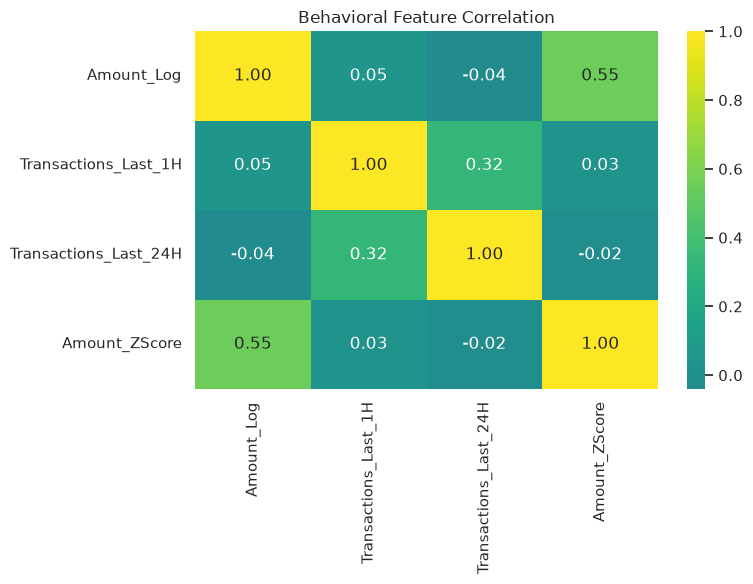

In [54]:
behavioral_numeric_for_corr = [
    c for c in BEHAVIORAL_FEATURES
    if c in df.columns
    and pd.api.types.is_numeric_dtype(df[c])
]

if len(behavioral_numeric_for_corr) >= 2:

    behavioral_corr = df[
        behavioral_numeric_for_corr
    ].corr()

    behavioral_corr.to_csv(
        RESULT_DIR / "behavioral_feature_correlation.csv"
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        behavioral_corr,
        annot=True,
        fmt=".2f",
        center=0,
        cmap="viridis"
    )

    plt.title("Behavioral Feature Correlation")
    plt.tight_layout()

    plt.show()

    plt.savefig(
        FIGURE_DIR / "behavioral_feature_correlation.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


## 16. Fraud Rate by Amount Category

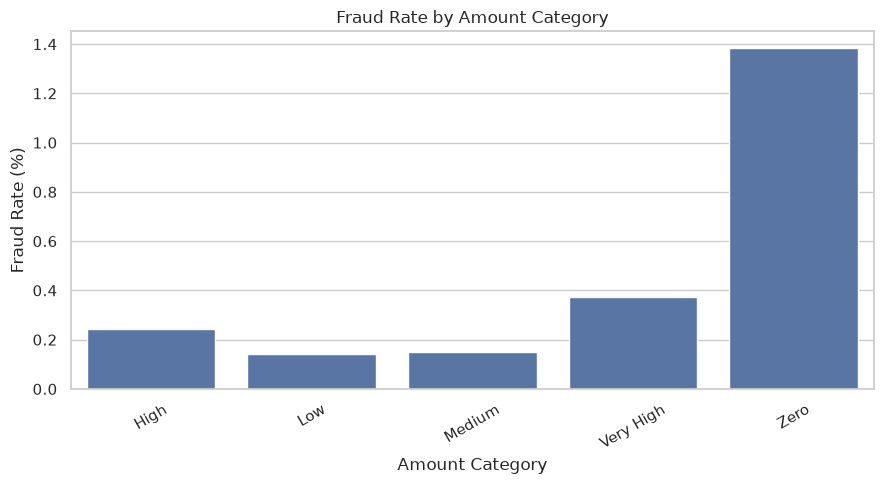

In [59]:
if "Amount_Category" in df.columns:

    amount_category = (
        df.groupby(
            "Amount_Category",
            observed=True
        )
        .agg(
            Transactions=("Class", "count"),
            Fraud_Count=("Class", "sum")
        )
        .reset_index()
    )

    amount_category["Fraud_Rate_Percent"] = (
        amount_category["Fraud_Count"]
        / amount_category["Transactions"]
        * 100
    )

    amount_category.to_csv(
        RESULT_DIR / "amount_category_fraud_rate.csv",
        index=False
    )

    table = pd.crosstab(
        df["Amount_Category"],
        df["Class"]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        table
    )

    n = table.to_numpy().sum()
    rows, cols = table.shape

    phi2 = chi2 / n

    phi2_corrected = max(
        0,
        phi2
        - ((cols - 1) * (rows - 1)) / max(n - 1, 1)
    )

    rows_corrected = (
        rows
        - ((rows - 1) ** 2) / max(n - 1, 1)
    )

    cols_corrected = (
        cols
        - ((cols - 1) ** 2) / max(n - 1, 1)
    )

    denominator = min(
        cols_corrected - 1,
        rows_corrected - 1
    )

    amount_cramers_v = (
        np.sqrt(phi2_corrected / denominator)
        if denominator > 0
        else np.nan
    )

    amount_test = pd.DataFrame({
        "Test": [
            "Chi-square",
            "Cramer's V"
        ],
        "Value": [
            chi2,
            amount_cramers_v
        ],
        "P_Value": [
            p_value,
            np.nan
        ]
    })

    amount_test.to_csv(
        RESULT_DIR / "amount_category_test.csv",
        index=False
    )

    plt.figure(figsize=(9, 5))

    sns.barplot(
        data=amount_category,
        x="Amount_Category",
        y="Fraud_Rate_Percent"
    )

    plt.title("Fraud Rate by Amount Category")
    plt.xlabel("Amount Category")
    plt.ylabel("Fraud Rate (%)")
    plt.xticks(rotation=30)
    plt.tight_layout()

    plt.show()

    plt.savefig(
        FIGURE_DIR / "amount_category_fraud_rate.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


In [61]:
print("\nAmount Category:")
print(f"Chi-square : {chi2:.6f}")
print(f"p-value    : {p_value:.6e}")
print(f"Cramer's V : {amount_cramers_v:.6f}")


Amount Category:
Chi-square : 198.750655
p-value    : 6.973817e-42
Cramer's V : 0.026199


## 17. Temporal Fraud Analysis

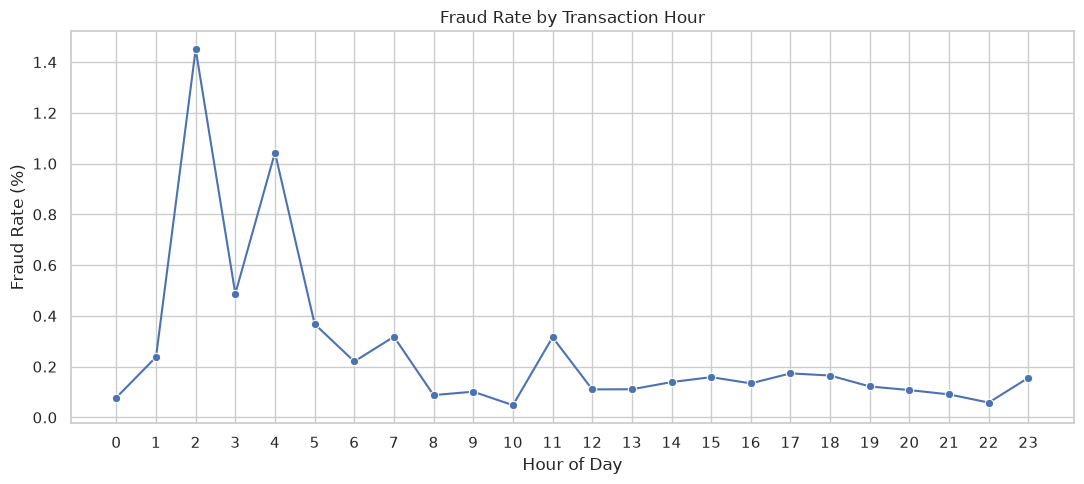

In [69]:
if "Transaction_Hour_Int" in df.columns:

    hourly = (
        df.groupby("Transaction_Hour_Int")
        .agg(
            Transactions=("Class", "count"),
            Fraud_Count=("Class", "sum")
        )
        .reset_index()
    )

    hourly["Fraud_Rate_Percent"] = (
        hourly["Fraud_Count"]
        / hourly["Transactions"]
        * 100
    )

    hourly.to_csv(
        RESULT_DIR / "hourly_fraud_analysis.csv",
        index=False
    )

    plt.figure(figsize=(11, 5))

    sns.lineplot(
        data=hourly,
        x="Transaction_Hour_Int",
        y="Fraud_Rate_Percent",
        marker="o"
    )

    plt.xticks(range(24))
    plt.xlabel("Hour of Day")
    plt.ylabel("Fraud Rate (%)")
    plt.title("Fraud Rate by Transaction Hour")
    plt.tight_layout()

    plt.show()

    plt.savefig(
        FIGURE_DIR / "fraud_rate_by_hour.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


## 18. XGBoost Feature Importance

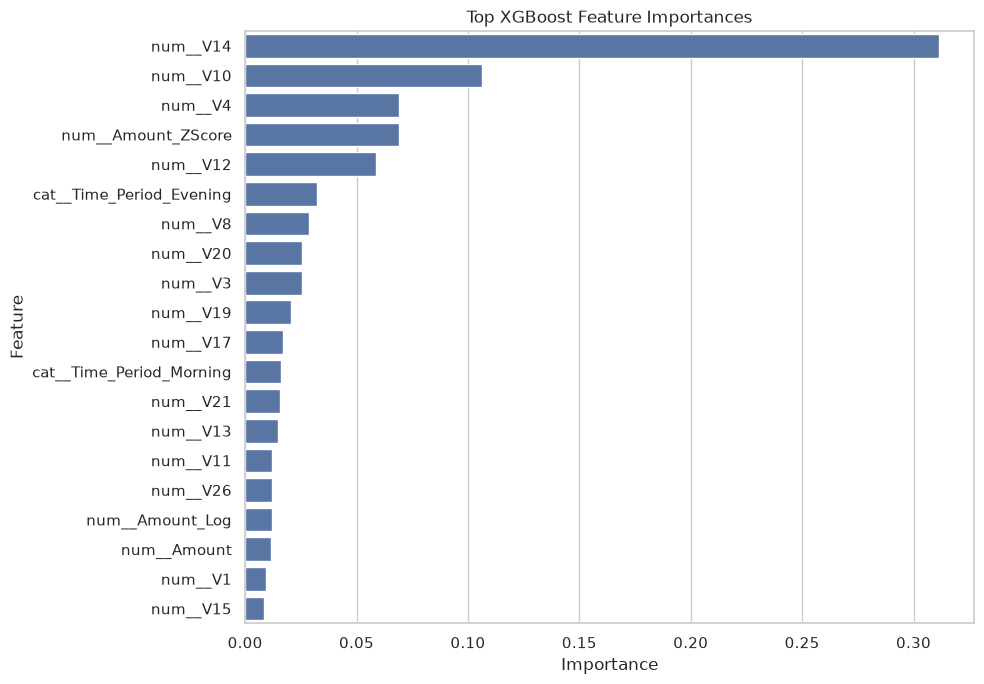

                 Feature  Importance
                num__V14    0.311548
                num__V10    0.106448
                 num__V4    0.068993
      num__Amount_ZScore    0.068902
                num__V12    0.058797
cat__Time_Period_Evening    0.032244
                 num__V8    0.028838
                num__V20    0.025520
                 num__V3    0.025324
                num__V19    0.020720
                num__V17    0.016880
cat__Time_Period_Morning    0.016241
                num__V21    0.015591
                num__V13    0.014939
                num__V11    0.012213
                num__V26    0.012122
         num__Amount_Log    0.012054
             num__Amount    0.011523
                 num__V1    0.009222
                num__V15    0.008585


In [70]:
xgb_pipeline = fitted_models["XGBoost"]

preprocessor_fitted = xgb_pipeline.named_steps["preprocessor"]
xgb_model = xgb_pipeline.named_steps["model"]

try:
    transformed_names = (
        preprocessor_fitted
        .get_feature_names_out()
    )

    importance_values = (
        xgb_model.feature_importances_
    )

    importance_df = pd.DataFrame({
        "Feature": transformed_names,
        "Importance": importance_values
    }).sort_values(
        "Importance",
        ascending=False
    )

    importance_df.to_csv(
        RESULT_DIR / "xgboost_feature_importance.csv",
        index=False
    )

    top_importance = importance_df.head(20)

    plt.figure(figsize=(10, 7))

    sns.barplot(
        data=top_importance,
        x="Importance",
        y="Feature"
    )

    plt.title("Top XGBoost Feature Importances")
    plt.tight_layout()

    plt.show()

    plt.savefig(
        FIGURE_DIR / "xgboost_feature_importance.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(
        top_importance.round(6).to_string(index=False)
    )

except Exception as exc:
    print(
        "Feature importance extraction skipped:",
        repr(exc)
    )
    importance_df = pd.DataFrame()


## 19. Model vs. Statistical Evidence

This table does not claim that statistical significance equals predictive importance. It simply presents the evidence sources side by side.

In [71]:
stat_lookup = stat_df.set_index("Feature")

comparison_rows = []

for feature in BEHAVIORAL_FEATURES:

    if feature not in stat_lookup.index:
        continue

    row = stat_lookup.loc[feature]

    comparison_rows.append({
        "Feature": feature,
        "Adjusted_P_Value": row["Adjusted_P_Value"],
        "Cliffs_Delta": row["Cliffs_Delta"],
        "Effect_Size": row["Effect_Size"],
    })

behavioral_evidence_df = pd.DataFrame(
    comparison_rows
)

behavioral_evidence_df.to_csv(
    RESULT_DIR / "behavioral_evidence_summary.csv",
    index=False
)


In [77]:
behavioral_evidence_df 


,Feature,Adjusted_P_Value,Cliffs_Delta,Effect_Size
0,Amount_Log,3.223308e-05,-0.111543,Negligible
1,Transactions_Last_1H,9.114461e-09,-0.154307,Small
2,Transactions_Last_24H,5.316910e-08,-0.146077,Negligible
3,Amount_ZScore,3.223308e-05,-0.111543,Negligible


## 20. Save Model Benchmark

In [79]:
model_results_df

,Model,Precision,Recall,F1,PR_AUC,ROC_AUC,Balanced_Accuracy,TN,FP,FN,TP
0,Logistic Regression,0.050672,0.873684,0.095788,0.689603,0.969391,0.923118,55096,1555,12,83
1,Random Forest,0.945946,0.736842,0.828402,0.811804,0.948933,0.868386,56647,4,25,70
2,XGBoost,0.925926,0.789474,0.852273,0.810501,0.966187,0.894684,56645,6,20,75


In [80]:
threshold_comparison

,Metric,Default_0.50,Validation_Selected_Threshold
0,Precision,0.925926,0.925926
1,Recall,0.789474,0.789474
2,F1,0.852273,0.852273


In [81]:

model_results_df.to_csv(
    RESULT_DIR / "model_benchmark.csv",
    index=False
)

threshold_comparison.to_csv(
    RESULT_DIR / "xgboost_threshold_comparison.csv",
    index=False
)


## 21. Final Project Summary

In [82]:
best_model_row = model_results_df.loc[
    model_results_df["PR_AUC"].idxmax()
]

best_model_name = best_model_row["Model"]

# Number of statistically strong numerical features.
large_effect_count = int(
    (stat_df["Effect_Size"] == "Large").sum()
)

medium_effect_count = int(
    (stat_df["Effect_Size"] == "Medium").sum()
)

small_effect_count = int(
    (stat_df["Effect_Size"] == "Small").sum()
)

In [83]:
summary = {
    "dataset_size": int(len(df)),
    "normal_transactions": normal_count,
    "fraud_transactions": fraud_count,
    "fraud_rate": float(fraud_rate),

    "best_model_by_pr_auc": best_model_name,
    "best_model_pr_auc": float(best_model_row["PR_AUC"]),
    "best_model_roc_auc": float(best_model_row["ROC_AUC"]),
    "best_model_precision": float(best_model_row["Precision"]),
    "best_model_recall": float(best_model_row["Recall"]),
    "best_model_f1": float(best_model_row["F1"]),

    "xgboost_validation_best_threshold": best_threshold,

    "large_effect_numerical_features": large_effect_count,
    "medium_effect_numerical_features": medium_effect_count,
    "small_effect_numerical_features": small_effect_count,

    "behavioral_features_analyzed": BEHAVIORAL_FEATURES,
}


In [84]:
with open(
    RESULT_DIR / "final_summary.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        indent=4
    )

In [87]:
with open(
    RESULT_DIR / "FINAL_PROJECT_SUMMARY.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "BEHAVIORGUARD — FINAL PROJECT SUMMARY:\n\n"
        
    )

    f.write(
        f"Dataset size: {len(df):,}\n"
    )

    f.write(
        f"Normal transactions: {normal_count:,}\n"
    )

    f.write(
        f"Fraud transactions: {fraud_count:,}\n"
    )

    f.write(
        f"Fraud rate: {fraud_rate:.4%}\n\n"
    )

    f.write(
        "MODEL BENCHMARK\n"
        "---------------\n"
    )

    f.write(
        model_results_df[
            [
                "Model",
                "Precision",
                "Recall",
                "F1",
                "PR_AUC",
                "ROC_AUC",
            ]
        ]
        .round(4)
        .to_string(index=False)
    )

    f.write("\n\n")

    f.write(
        f"Best model by PR-AUC: {best_model_name}\n"
    )

    f.write(
        f"XGBoost validation-selected threshold: "
        f"{best_threshold:.2f}\n\n"
    )

    f.write(
        "TOP STATISTICAL FEATURES\n"
        "------------------------\n"
    )

    f.write(
        stat_df[
            [
                "Feature",
                "Adjusted_P_Value",
                "Cliffs_Delta",
                "Effect_Size",
            ]
        ]
        .head(15)
        .round(6)
        .to_string(index=False)
    )

    f.write("\n\n")

    f.write(
        "BEHAVIORAL FEATURES\n"
        "-------------------\n"
    )

    if not behavioral_evidence_df.empty:

        f.write(
            behavioral_evidence_df.round(6)
            .to_string(index=False)
        )

    f.write("\n\n")

    f.write(
        "INTERPRETATION\n"
        "--------------\n"
        "1. The dataset is extremely imbalanced, so PR-AUC, recall, "
        "precision and F1 are more informative than accuracy alone.\n"
        "2. Several anonymized V-features show very strong statistical "
        "separation between normal and fraudulent transactions.\n"
        "3. Engineered behavioral features should be interpreted as "
        "complementary signals rather than automatically assuming they "
        "are individually strong fraud predictors.\n"
        "4. Statistical significance is interpreted together with effect "
        "size because the dataset is large.\n"
        "5. The XGBoost threshold is selected on validation data and the "
        "test set is used only for final evaluation.\n"
    )

## Final Console Report

In [88]:
print(f"\nDataset size       : {len(df):,}")
print(f"Normal transactions: {normal_count:,}")
print(f"Fraud transactions : {fraud_count:,}")
print(f"Fraud rate         : {fraud_rate:.4%}")

print("\nModel benchmark:")
print(
    model_results_df[
        [
            "Model",
            "Precision",
            "Recall",
            "F1",
            "PR_AUC",
            "ROC_AUC",
        ]
    ].round(4).to_string(index=False)
)

print(
    f"\nBest model by PR-AUC: {best_model_name}"
)

print(
    f"XGBoost validation-selected threshold: "
    f"{best_threshold:.2f}"
)

print(
    f"\nLarge-effect numerical features: {large_effect_count}"
)

print(
    f"Medium-effect numerical features: {medium_effect_count}"
)

print(
    f"Small-effect numerical features: {small_effect_count}"
)

print("\nTop 10 statistical features:")
print(
    stat_df[
        [
            "Feature",
            "Adjusted_P_Value",
            "Cliffs_Delta",
            "Effect_Size",
        ]
    ]
    .head(10)
    .round(6)
    .to_string(index=False)
)

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)

print(
    "\nAll final outputs were saved to:"
    f"\n{RESULT_DIR.resolve()}"
)

print(
    "\nImportant files:"
    "\n- model_benchmark.csv"
    "\n- xgboost_threshold_comparison.csv"
    "\n- statistical_numerical_features.csv"
    "\n- statistical_categorical_features.csv"
    "\n- behavioral_feature_evidence.csv"
    "\n- xgboost_feature_importance.csv"
    "\n- FINAL_PROJECT_SUMMARY.txt"
    "\n- final_summary.json"
    "\n- figures/"
    "\n- models/"
)



Dataset size       : 283,726
Normal transactions: 283,253
Fraud transactions : 473
Fraud rate         : 0.1667%

Model benchmark:
              Model  Precision  Recall     F1  PR_AUC  ROC_AUC
Logistic Regression     0.0507  0.8737 0.0958  0.6896   0.9694
      Random Forest     0.9459  0.7368 0.8284  0.8118   0.9489
            XGBoost     0.9259  0.7895 0.8523  0.8105   0.9662

Best model by PR-AUC: Random Forest
XGBoost validation-selected threshold: 0.54

Large-effect numerical features: 14
Medium-effect numerical features: 3
Small-effect numerical features: 8

Top 10 statistical features:
Feature  Adjusted_P_Value  Cliffs_Delta Effect_Size
    V14               0.0     -0.894278       Large
     V4               0.0      0.872511       Large
    V12               0.0     -0.868913       Large
    V11               0.0      0.829646       Large
    V10               0.0     -0.821164       Large
     V3               0.0     -0.817280       Large
     V2               0.0      0.6